# Tarea: Árboles de Decisión para Clasificación
## Clasificación con Decision Tree usando Gini Index y Entropy

**Nombre:** John David Ortega E.  
**Fecha:** 28/06/2026  

### Objetivo:
Familiarizar al estudiante con los Árboles de Decisión para clasificación, implementando modelos con diferentes criterios de división (Gini Index y Entropy), analizando el efecto de los hiperparámetros como `max_depth` en el rendimiento del modelo, y comparando los resultados mediante métricas de evaluación y visualización del árbol.

### Instrucciones:
1. Ejecute cada celda de código en orden.
2. **En las celdas de código marcadas con '# TODO:', implemente el código requerido siguiendo las instrucciones.**
3. Ejecute las celdas implementadas y responda las preguntas de selección múltiple.
4. Marque sus respuestas claramente.
5. Experimente modificando hiperparámetros cuando se indique.

### Descripción del Dataset:
Utilizaremos el **Car Evaluation Dataset** del UCI Machine Learning Repository. Este dataset contiene información sobre evaluación de automóviles basada en 6 atributos:
- **buying**: Precio de compra (vhigh, high, med, low)
- **maint**: Costo de mantenimiento (vhigh, high, med, low)
- **doors**: Número de puertas (2, 3, 4, 5more)
- **persons**: Capacidad de personas (2, 4, more)
- **lug_boot**: Tamaño del maletero (small, med, big)
- **safety**: Seguridad estimada (low, med, high)

**Variable objetivo (class):** Evaluación del auto (unacc, acc, good, vgood)

### Archivo requerido:
- `car.data` - Dataset de evaluación de automóviles

## Parte 1: Configuración y Carga de Datos

In [10]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings("ignore")

# Ajustes sencillos para que los gráficos se vean mejor
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10
sns.set_style("whitegrid")


In [11]:
# TODO: Cargar el dataset car.data
#
# Instrucciones:
# 1. Defina los nombres de columnas en una lista:
#    col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']
# 2. Use pd.read_csv() para cargar 'car.data' con header=None y names=col_names
# 3. Imprima las dimensiones del dataset con df.shape
# 4. Muestre las primeras 5 filas con df.head()

# Nombres de columnas del dataset
nombres_columnas = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

# Cargar el archivo
df = pd.read_csv("car.data", header=None, names=nombres_columnas)

# Revisar forma general del dataset
print("Dimensiones del dataset:", df.shape)

# Mostrar primeras filas
display(df.head())

Dimensiones del dataset: (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


### Pregunta 1: Dimensiones del Dataset
¿Cuántas muestras y características tiene el dataset?

A) 1728 muestras, 6 características  
B) 1728 muestras, 7 características  
C) 1000 muestras, 6 características  
D) 2000 muestras, 7 características  

**Su Respuesta:** B

## Parte 2: Análisis Exploratorio de Datos (EDA)

In [12]:
# TODO: Explorar información del dataset
#
# Instrucciones:
# 1. Use df.info() para ver tipos de datos y valores no nulos
# 2. Use df.describe() para estadísticas descriptivas

# Información general del DataFrame
print("Información general del dataset:\n")
print(df.info())

# Estadísticas descriptivas para variables categóricas
print("\nEstadísticas descriptivas:")
display(df.describe(include="object"))


Información general del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB
None

Estadísticas descriptivas:


,buying,maint,doors,persons,lug_boot,safety,class
count,1728,1728,1728,1728,1728,1728,1728
unique,4,4,4,3,3,3,4
top,vhigh,vhigh,2,2,small,low,unacc
freq,432,432,432,576,576,576,1210


In [13]:
# TODO: Verificar valores únicos por columna
#
# Instrucciones:
# 1. Use un loop for para recorrer df.columns
# 2. Para cada columna, imprima df[col].unique()

# Recorrer cada columna para ver sus categorías
for columna in df.columns:
    print(f"\nColumna: {columna}")

    # Mostrar valores únicos
    print(df[columna].unique())



Columna: buying
['vhigh' 'high' 'med' 'low']

Columna: maint
['vhigh' 'high' 'med' 'low']

Columna: doors
['2' '3' '4' '5more']

Columna: persons
['2' '4' 'more']

Columna: lug_boot
['small' 'med' 'big']

Columna: safety
['low' 'med' 'high']

Columna: class
['unacc' 'acc' 'vgood' 'good']


In [14]:
# TODO: Verificar valores nulos
#
# Instrucciones:
# 1. Use df.isnull().sum() para contar valores nulos por columna

# Contar valores nulos por columna
print("Valores nulos por columna:")
print(df.isnull().sum())


Valores nulos por columna:
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64


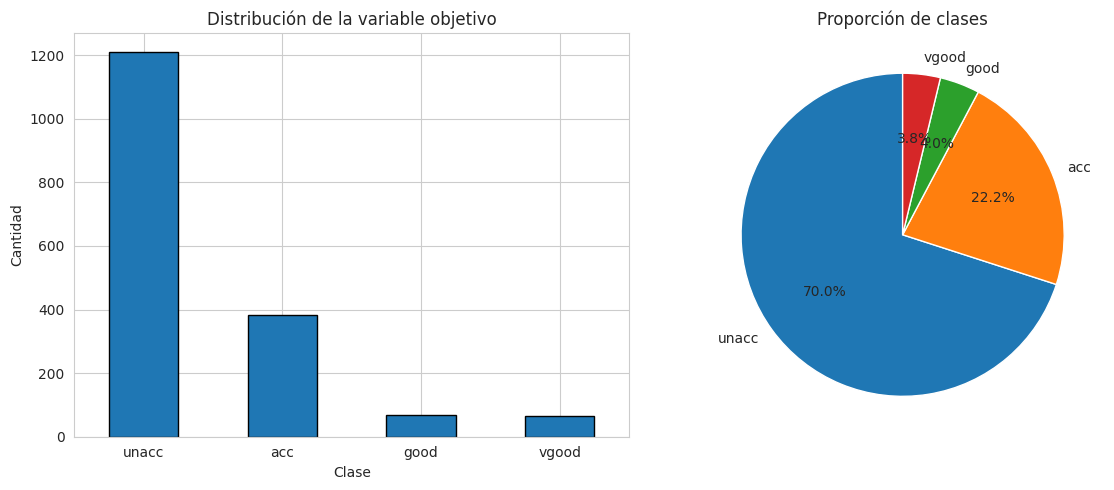

Conteo de clases:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [15]:
# TODO: Visualizar la distribución de la variable objetivo
#
# Instrucciones:
# 1. Cree una figura con 2 subplots (1 fila, 2 columnas)
# 2. En el primer subplot, use df['class'].value_counts().plot(kind='bar')
# 3. En el segundo subplot, use df['class'].value_counts().plot(kind='pie', autopct='%1.1f%%')
# 4. Agregue títulos y etiquetas apropiadas
# 5. Imprima el conteo de clases con df['class'].value_counts()

# Crear figura con dos gráficos
fig, ejes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
df['class'].value_counts().plot(kind='bar', ax=ejes[0], edgecolor='black')
ejes[0].set_title('Distribución de la variable objetivo')
ejes[0].set_xlabel('Clase')
ejes[0].set_ylabel('Cantidad')
ejes[0].tick_params(axis='x', rotation=0)

# Gráfico circular
df['class'].value_counts().plot(kind='pie', ax=ejes[1], autopct='%1.1f%%', startangle=90)
ejes[1].set_title('Proporción de clases')
ejes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Mostrar conteo exacto
print("Conteo de clases:")
print(df['class'].value_counts())


### Pregunta 2: Distribución de Clases
¿Cuál es la clase más frecuente en el dataset?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C

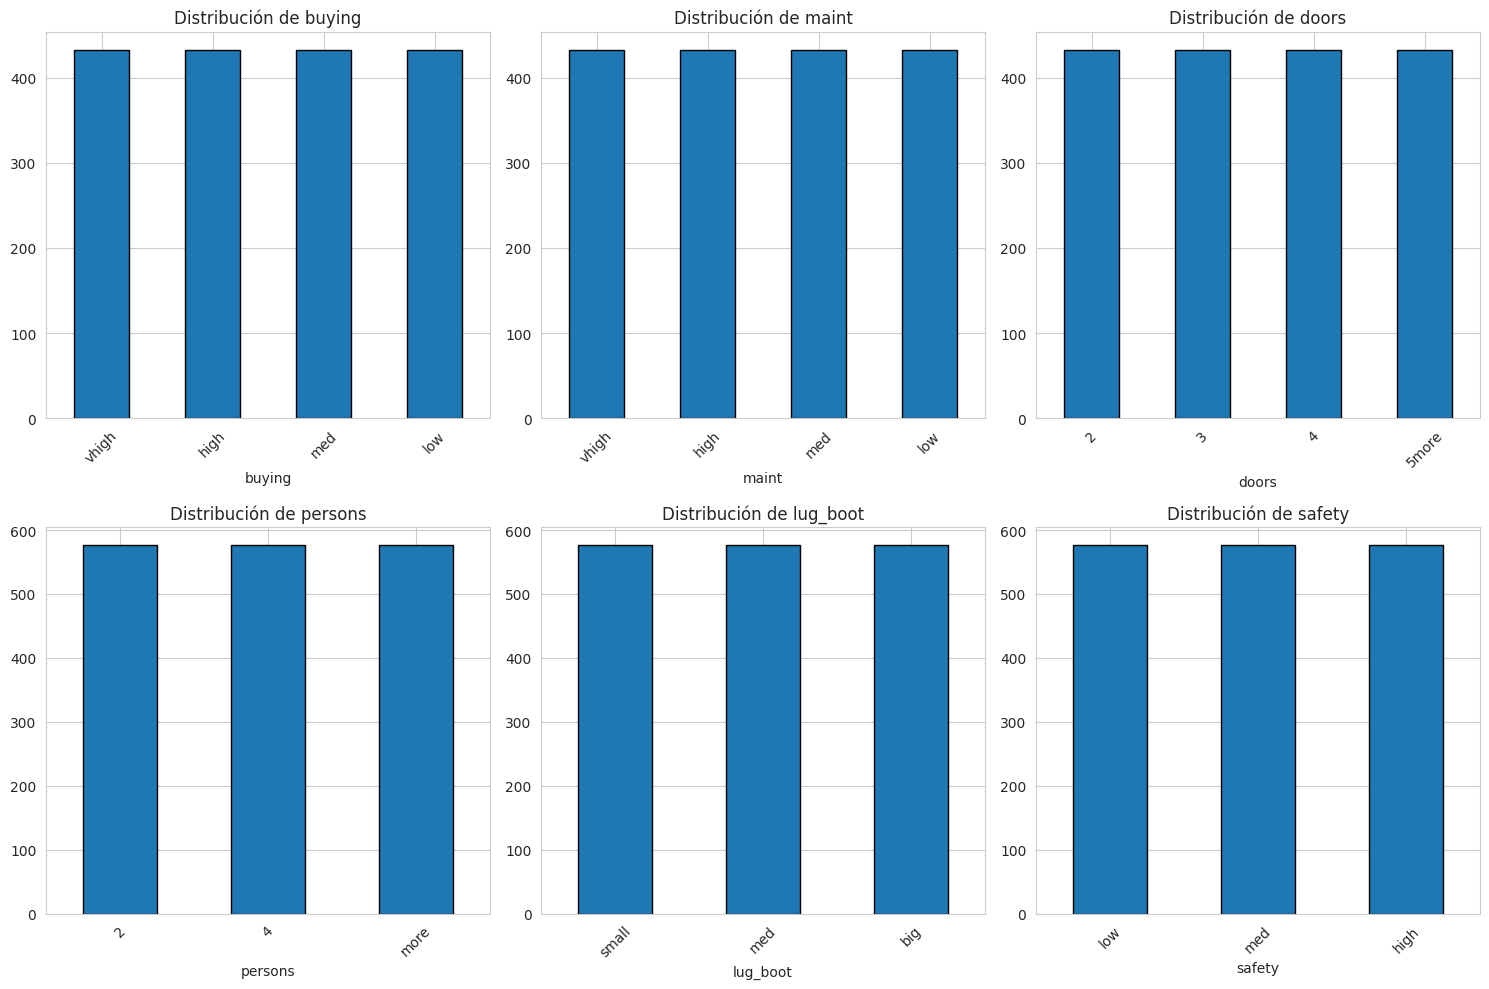

In [16]:
# TODO: Visualizar distribución de características
#
# Instrucciones:
# 1. Cree una figura con subplots 2x3 usando plt.subplots(2, 3, figsize=(15, 10))
# 2. Defina features = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']
# 3. Use un loop para graficar df[feature].value_counts().plot(kind='bar') en cada subplot
# 4. Agregue títulos a cada subplot

# Lista de variables predictoras
caracteristicas = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']

# Crear subplots
fig, ejes = plt.subplots(2, 3, figsize=(15, 10))
ejes = ejes.flatten()

# Graficar cada característica
for i, caracteristica in enumerate(caracteristicas):
    df[caracteristica].value_counts().plot(kind='bar', ax=ejes[i], edgecolor='black')
    ejes[i].set_title(f'Distribución de {caracteristica}')
    ejes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Pregunta 3: Balance del Dataset
¿El dataset está balanceado respecto a la variable objetivo?

A) Sí, todas las clases tienen la misma frecuencia  
B) No, hay un fuerte desbalance (unacc es la mayoritaria con >70%)  
C) No, pero el desbalance es leve  
D) No se puede determinar  

**Su Respuesta:** B

## Parte 3: Preprocesamiento - Label Encoding

### Teoría:
Los árboles de decisión en Scikit-Learn requieren que las variables categóricas sean convertidas a valores numéricos. Usaremos **Label Encoding** para transformar cada categoría en un número entero.

In [17]:
# TODO: Aplicar Label Encoding a todas las columnas
#
# Instrucciones:
# 1. Cree una copia del DataFrame: df_encoded = df.copy()
# 2. Cree un diccionario vacío: label_encoders = {}
# 3. Para cada columna en df_encoded.columns:
#    a. Cree un LabelEncoder: le = LabelEncoder()
#    b. Transforme la columna: df_encoded[col] = le.fit_transform(df_encoded[col])

# Crear copia del DataFrame original
df_codificado = df.copy()

# Diccionario para guardar los encoders
codificadores = {}

# Codificar cada columna
for columna in df_codificado.columns:
    codificador = LabelEncoder()
    df_codificado[columna] = codificador.fit_transform(df_codificado[columna])
    codificadores[columna] = codificador

# Mostrar resultado
display(df_codificado.head())


,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [18]:
# TODO: Mostrar el mapeo de etiquetas
#
# Instrucciones:
# 1. Para cada columna y encoder en label_encoders.items():
#    - Imprima el mapeo usando dict(zip(le.classes_, range(len(le.classes_))))

# Mostrar cómo quedó codificada cada columna
for columna, codificador in codificadores.items():
    print(f"\nMapeo para {columna}:")
    print(dict(zip(codificador.classes_, range(len(codificador.classes_)))))



Mapeo para buying:
{'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}

Mapeo para maint:
{'high': 0, 'low': 1, 'med': 2, 'vhigh': 3}

Mapeo para doors:
{'2': 0, '3': 1, '4': 2, '5more': 3}

Mapeo para persons:
{'2': 0, '4': 1, 'more': 2}

Mapeo para lug_boot:
{'big': 0, 'med': 1, 'small': 2}

Mapeo para safety:
{'high': 0, 'low': 1, 'med': 2}

Mapeo para class:
{'acc': 0, 'good': 1, 'unacc': 2, 'vgood': 3}


### Pregunta 4: Label Encoding
¿Qué hace Label Encoding?

A) Elimina las variables categóricas  
B) Convierte categorías a valores numéricos enteros  
C) Normaliza los datos entre 0 y 1  
D) Crea variables dummy (one-hot encoding)  

**Su Respuesta:** B

## Parte 4: División de Datos

In [19]:
# TODO: Separar características (X) y variable objetivo (y)
#
# Instrucciones:
# 1. X = df_encoded.drop('class', axis=1) para obtener solo las características
# 2. y = df_encoded['class'] para obtener la variable objetivo
# 3. Imprima las formas de X y y
# 4. Imprima los nombres de las características con list(X.columns)

# Separar variables predictoras y variable objetivo
X = df_codificado.drop('class', axis=1)
y = df_codificado['class']

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Nombres de las características:", list(X.columns))


Forma de X: (1728, 6)
Forma de y: (1728,)
Nombres de las características: ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety']


In [20]:
# TODO: Dividir en conjuntos de entrenamiento y prueba
#
# Instrucciones:
# 1. Use train_test_split(X, y, test_size=0.33, random_state=42)
# 2. Asigne a X_train, X_test, y_train, y_test
# 3. Imprima los tamaños de cada conjunto

# Dividir los datos en entrenamiento y prueba
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X, y, test_size=0.33, random_state=42
)

print("Tamaño de X_entrenamiento:", X_entrenamiento.shape)
print("Tamaño de X_prueba:", X_prueba.shape)
print("Tamaño de y_entrenamiento:", y_entrenamiento.shape)
print("Tamaño de y_prueba:", y_prueba.shape)


Tamaño de X_entrenamiento: (1157, 6)
Tamaño de X_prueba: (571, 6)
Tamaño de y_entrenamiento: (1157,)
Tamaño de y_prueba: (571,)


### Pregunta 5: División de Datos
Con test_size=0.33, ¿cuál es aproximadamente el tamaño del conjunto de entrenamiento?

A) 570 muestras  
B) 1157 muestras  
C) 1728 muestras  
D) 864 muestras  

**Su Respuesta:** C

## Parte 5: Árbol de Decisión con Criterio Gini Index

### Teoría - Gini Index:
El índice Gini mide la impureza de un nodo. Se calcula como:

$$Gini = 1 - \sum_{i=1}^{n} p_i^2$$

Donde $p_i$ es la probabilidad de la clase $i$ en el nodo. Un Gini de 0 indica pureza perfecta.

In [21]:
# TODO: Crear y entrenar el modelo con criterio Gini
#
# Instrucciones:
# 1. Cree el clasificador: clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
# 2. Entrene con clf_gini.fit(X_train, y_train)
# 3. Imprima la profundidad del árbol con clf_gini.get_depth()
# 4. Imprima el número de hojas con clf_gini.get_n_leaves()

# Crear el árbol con criterio Gini
modelo_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

# Entrenar el modelo
modelo_gini.fit(X_entrenamiento, y_entrenamiento)

# Mostrar profundidad y hojas
print("Profundidad del árbol:", modelo_gini.get_depth())
print("Número de hojas:", modelo_gini.get_n_leaves())


Profundidad del árbol: 3
Número de hojas: 5


In [22]:
# TODO: Realizar predicciones y evaluar
#
# Instrucciones:
# 1. Prediga con y_pred_gini = clf_gini.predict(X_test)
# 2. Calcule la precisión en test con accuracy_score(y_test, y_pred_gini)
# 3. Prediga en train y calcule la precisión en entrenamiento
# 4. Imprima ambas precisiones

# Predicciones en prueba y entrenamiento
pred_prueba_gini = modelo_gini.predict(X_prueba)
pred_entrenamiento_gini = modelo_gini.predict(X_entrenamiento)

# Accuracy en prueba y entrenamiento
precision_prueba_gini = accuracy_score(y_prueba, pred_prueba_gini)
precision_entrenamiento_gini = accuracy_score(y_entrenamiento, pred_entrenamiento_gini)

print("Precisión en entrenamiento:", round(precision_entrenamiento_gini, 4))
print("Precisión en prueba:", round(precision_prueba_gini, 4))


Precisión en entrenamiento: 0.7744
Precisión en prueba: 0.7653


### Pregunta 6: Precisión con Gini (max_depth=3)
¿Cuál es la precisión aproximada del modelo con Gini Index y max_depth=3?

A) 60-70%  
B) 70-80%  
C) 80-90%  
D) 90-100%  

**Su Respuesta:** B

## Parte 6: Árbol de Decisión con Criterio Entropy

### Teoría - Entropy (Information Gain):
La entropía mide el desorden o incertidumbre. Se calcula como:

$$Entropy = -\sum_{i=1}^{n} p_i \log_2(p_i)$$

El **Information Gain** es la reducción de entropía después de una división.

In [23]:
# TODO: Crear y entrenar el modelo con criterio Entropy
#
# Instrucciones:
# 1. Cree el clasificador: clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
# 2. Entrene con clf_entropy.fit(X_train, y_train)
# 3. Imprima la profundidad y número de hojas

# Crear el árbol con criterio Entropy
modelo_entropia = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)

# Entrenar el modelo
modelo_entropia.fit(X_entrenamiento, y_entrenamiento)

print("Profundidad del árbol:", modelo_entropia.get_depth())
print("Número de hojas:", modelo_entropia.get_n_leaves())


Profundidad del árbol: 3
Número de hojas: 5


In [24]:
# TODO: Realizar predicciones y evaluar
#
# Instrucciones:
# 1. Prediga con clf_entropy.predict(X_test)
# 2. Calcule y muestre la precisión en test y train

# Predicciones con el modelo Entropy
pred_prueba_entropia = modelo_entropia.predict(X_prueba)
pred_entrenamiento_entropia = modelo_entropia.predict(X_entrenamiento)

# Accuracy en prueba y entrenamiento
precision_prueba_entropia = accuracy_score(y_prueba, pred_prueba_entropia)
precision_entrenamiento_entropia = accuracy_score(y_entrenamiento, pred_entrenamiento_entropia)

print("Precisión en entrenamiento:", round(precision_entrenamiento_entropia, 4))
print("Precisión en prueba:", round(precision_prueba_entropia, 4))


Precisión en entrenamiento: 0.7744
Precisión en prueba: 0.7653


### Pregunta 7: Comparación Gini vs Entropy
Con max_depth=3, ¿qué criterio obtiene mejor precisión?

A) Gini es significativamente mejor  
B) Entropy es significativamente mejor  
C) Ambos obtienen resultados muy similares  
D) No se puede comparar  

**Su Respuesta:** C

## Parte 7: Comparación de Modelos

In [25]:
# TODO: Crear tabla comparativa
#
# Instrucciones:
# 1. Cree un DataFrame con las siguientes columnas:
#    - 'Criterio': ['Gini Index', 'Entropy']
#    - 'Precisión Train': precisiones de entrenamiento
#    - 'Precisión Test': precisiones de prueba
#    - 'Profundidad': profundidad de cada árbol

# Crear tabla comparativa
tabla_comparativa = pd.DataFrame({
    'Criterio': ['Gini Index', 'Entropy'],
    'Precisión Train': [precision_entrenamiento_gini, precision_entrenamiento_entropia],
    'Precisión Test': [precision_prueba_gini, precision_prueba_entropia],
    'Profundidad': [modelo_gini.get_depth(), modelo_entropia.get_depth()]
})

display(tabla_comparativa)


,Criterio,Precisión Train,Precisión Test,Profundidad
0,Gini Index,0.774417,0.765324,3
1,Entropy,0.774417,0.765324,3


### Pregunta 8: Sobreajuste
Si la precisión en entrenamiento es mucho mayor que en prueba, ¿qué indica?

A) Subajuste (underfitting)  
B) Sobreajuste (overfitting)  
C) El modelo está bien ajustado  
D) Los datos son incorrectos  

**Su Respuesta:** B

## Parte 8: Matriz de Confusión y Métricas

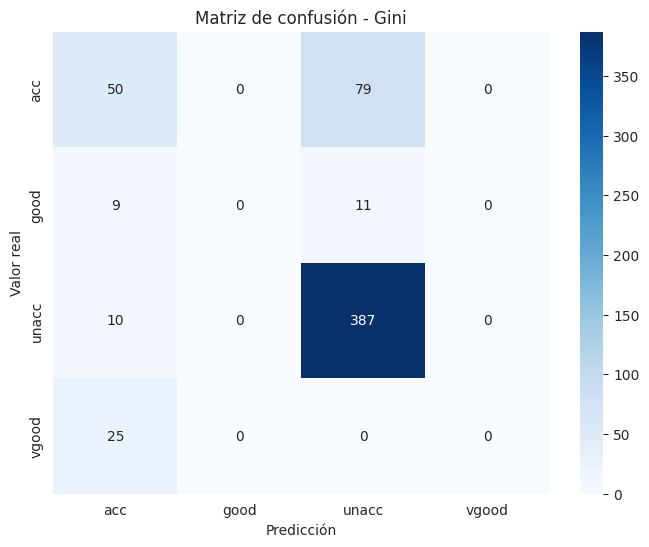

In [26]:
# TODO: Calcular y visualizar la matriz de confusión para el modelo Gini
#
# Instrucciones:
# 1. Calcule la matriz con confusion_matrix(y_test, y_pred_gini)
# 2. Obtenga los nombres de clase con label_encoders['class'].classes_
# 3. Use sns.heatmap() para visualizar con annot=True, fmt='d', cmap='Blues'
# 4. Configure xticklabels y yticklabels con los nombres de clase
# 5. Agregue título y etiquetas de ejes

# Calcular matriz de confusión
matriz_confusion = confusion_matrix(y_prueba, pred_prueba_gini)

# Recuperar nombres originales de clases
nombres_clases = codificadores['class'].classes_

# Dibujar heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nombres_clases,
    yticklabels=nombres_clases
)
plt.title('Matriz de confusión - Gini')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.show()


In [27]:
# TODO: Imprimir el reporte de clasificación
#
# Instrucciones:
# 1. Use classification_report(y_test, y_pred_gini, target_names=class_names)
# 2. Imprima el reporte

print("Reporte de clasificación - Gini\n")
print(classification_report(y_prueba, pred_prueba_gini, target_names=nombres_clases))


Reporte de clasificación - Gini

              precision    recall  f1-score   support

         acc       0.53      0.39      0.45       129
        good       0.00      0.00      0.00        20
       unacc       0.81      0.97      0.89       397
       vgood       0.00      0.00      0.00        25

    accuracy                           0.77       571
   macro avg       0.34      0.34      0.33       571
weighted avg       0.68      0.77      0.72       571



### Pregunta 9: Interpretación de la Matriz de Confusión
¿Qué clase tiene el mejor recall (sensibilidad) según el reporte?

A) acc (aceptable)  
B) good (bueno)  
C) unacc (inaceptable)  
D) vgood (muy bueno)  

**Su Respuesta:** C

## Parte 9: Visualización del Árbol de Decisión

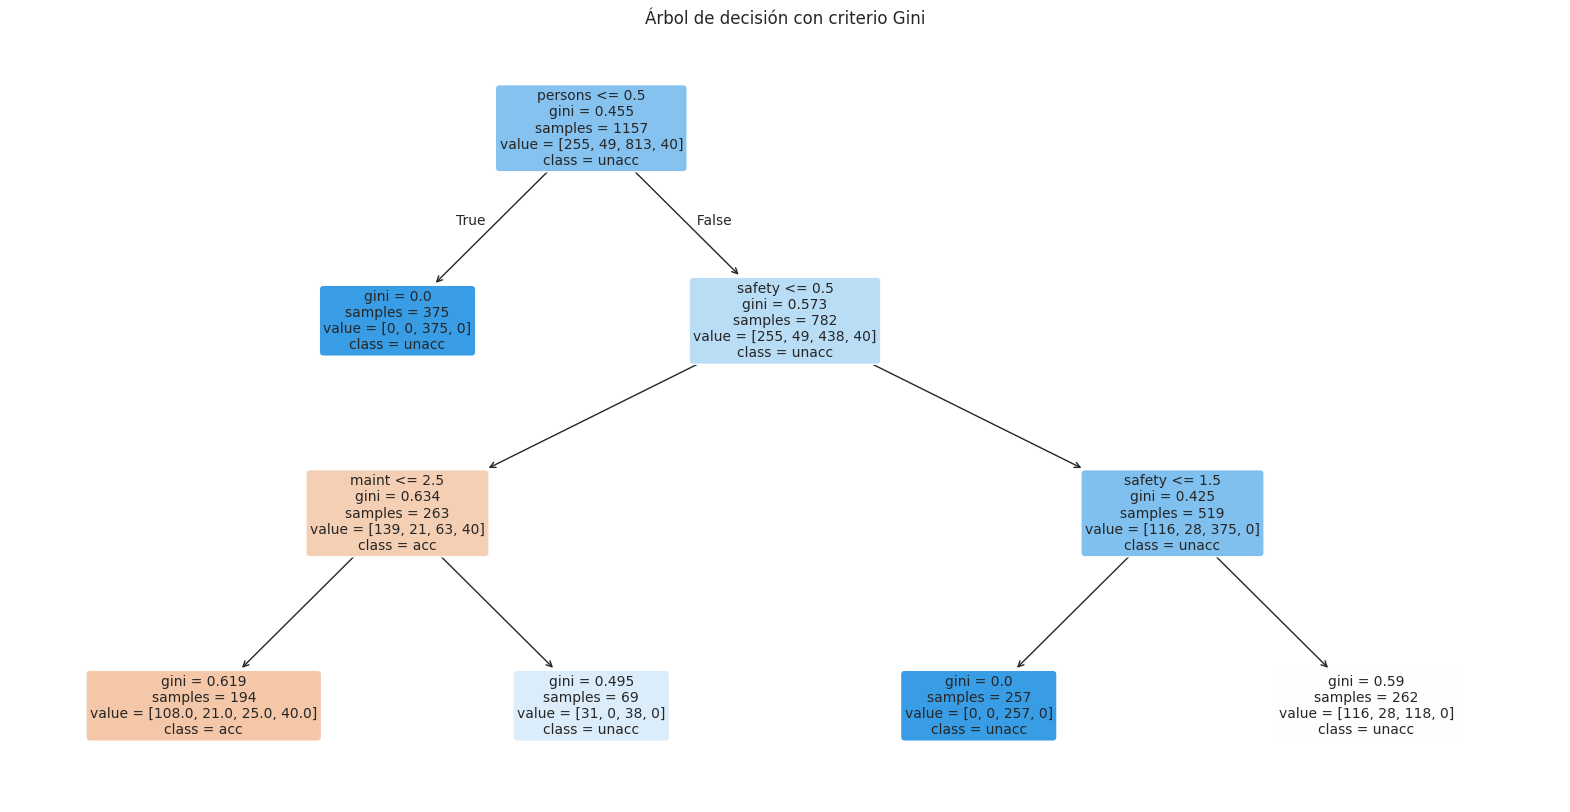

In [28]:
# TODO: Visualizar el árbol de decisión con Gini
#
# Instrucciones:
# 1. Cree una figura grande: plt.figure(figsize=(20, 10))
# 2. Use plot_tree() con los siguientes parámetros:
#    - clf_gini (el modelo)
#    - feature_names=list(X.columns)
#    - class_names=list(class_names)
#    - filled=True, rounded=True, fontsize=10

plt.figure(figsize=(20, 10))
plot_tree(
    modelo_gini,
    feature_names=list(X.columns),
    class_names=list(nombres_clases),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Árbol de decisión con criterio Gini')
plt.show()


,Característica,Importancia
5,safety,0.585506
3,persons,0.357400
1,maint,0.057095
0,buying,0.000000
2,doors,0.000000
4,lug_boot,0.000000


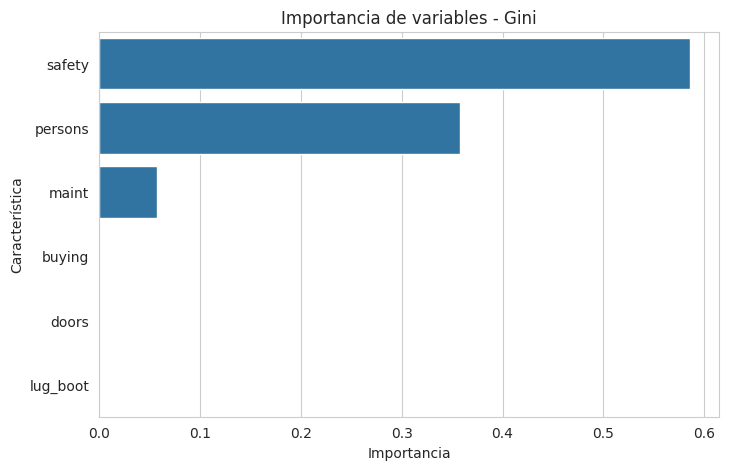

In [29]:
# TODO: Mostrar la importancia de las características
#
# Instrucciones:
# 1. Cree un DataFrame con columnas 'Feature' y 'Importance'
#    - 'Feature': X.columns
#    - 'Importance': clf_gini.feature_importances_
# 2. Ordene por importancia descendente con sort_values()
# 3. Visualice con sns.barplot()

# Crear tabla de importancia
importancia_variables = pd.DataFrame({
    'Característica': X.columns,
    'Importancia': modelo_gini.feature_importances_
}).sort_values(by='Importancia', ascending=False)

display(importancia_variables)

# Graficar importancia
plt.figure(figsize=(8, 5))
sns.barplot(data=importancia_variables, x='Importancia', y='Característica')
plt.title('Importancia de variables - Gini')
plt.show()


### Pregunta 10: Característica más Importante
¿Cuál es la característica más importante según el modelo con Gini?

A) buying (precio de compra)  
B) maint (mantenimiento)  
C) safety (seguridad)  
D) persons (capacidad de personas)  

**Su Respuesta:** C

## Parte 10: Experimentación con Hiperparámetros

In [30]:
# TODO: Experimentar con diferentes valores de max_depth
#
# Instrucciones:
# 1. Defina depths = [1, 2, 3, 5, 7, 10, None] (None = sin límite)
# 2. Cree una lista vacía para resultados
# 3. Para cada depth:
#    a. Cree y entrene un DecisionTreeClassifier con ese max_depth
#    b. Calcule precisión en train y test
#    c. Guarde también profundidad real y hojas
# 4. Muestre una tabla con los resultados

profundidades = [1, 2, 3, 5, 7, 10, None]
resultados_profundidad = []

for profundidad in profundidades:
    modelo = DecisionTreeClassifier(criterion='gini', max_depth=profundidad, random_state=42)
    modelo.fit(X_entrenamiento, y_entrenamiento)

    acc_train = accuracy_score(y_entrenamiento, modelo.predict(X_entrenamiento))
    acc_test = accuracy_score(y_prueba, modelo.predict(X_prueba))

    resultados_profundidad.append({
        'max_depth': str(profundidad),
        'Precisión Train': acc_train,
        'Precisión Test': acc_test,
        'Profundidad Real': modelo.get_depth(),
        'Hojas': modelo.get_n_leaves()
    })

tabla_profundidad = pd.DataFrame(resultados_profundidad)
display(tabla_profundidad)


,max_depth,Precisión Train,Precisión Test,Profundidad Real,Hojas
0,1,0.702679,0.695271,1,2
1,2,0.768366,0.770578,2,3
2,3,0.774417,0.765324,3,5
3,5,0.855661,0.865149,5,13
4,7,0.929991,0.935201,7,28
5,10,0.993086,0.961471,10,62
6,None,1.000000,0.966725,14,73


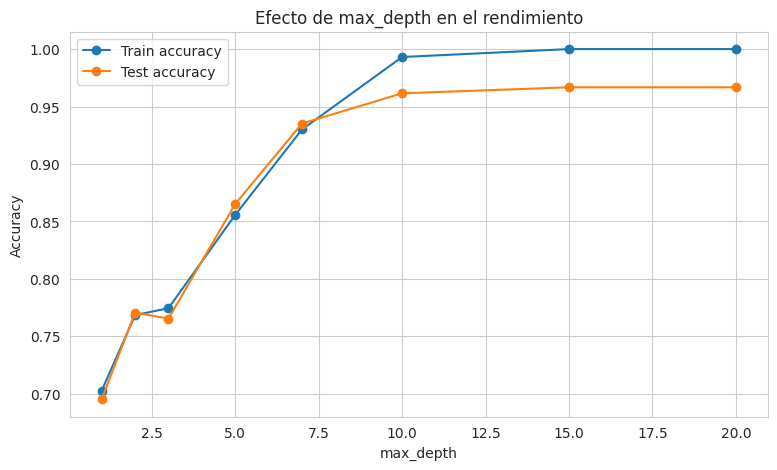

In [31]:
# TODO: Visualizar el efecto de max_depth
#
# Instrucciones:
# 1. Defina depths_plot = [1, 2, 3, 5, 7, 10, 15, 20]
# 2. Cree listas para train_scores y test_scores
# 3. Para cada depth, entrene un modelo y guarde las precisiones
# 4. Grafique ambas curvas (train y test) vs max_depth
# 5. Agregue leyenda, título y etiquetas

profundidades_grafico = [1, 2, 3, 5, 7, 10, 15, 20]
puntajes_train = []
puntajes_test = []

for profundidad in profundidades_grafico:
    modelo = DecisionTreeClassifier(criterion='gini', max_depth=profundidad, random_state=42)
    modelo.fit(X_entrenamiento, y_entrenamiento)
    puntajes_train.append(accuracy_score(y_entrenamiento, modelo.predict(X_entrenamiento)))
    puntajes_test.append(accuracy_score(y_prueba, modelo.predict(X_prueba)))

plt.figure(figsize=(9, 5))
plt.plot(profundidades_grafico, puntajes_train, marker='o', label='Train accuracy')
plt.plot(profundidades_grafico, puntajes_test, marker='o', label='Test accuracy')
plt.title('Efecto de max_depth en el rendimiento')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


### Pregunta 11: Efecto de max_depth
¿Qué ocurre cuando max_depth es muy alto (por ejemplo, 20 o None)?

A) El modelo mejora en test y train  
B) El modelo empeora en test y train  
C) Train accuracy sube pero test accuracy puede bajar (sobreajuste)  
D) No hay efecto significativo  

**Su Respuesta:** B

In [32]:
# TODO: Experimentar con min_samples_split
#
# Instrucciones:
# 1. Defina min_samples_list = [2, 5, 10, 20, 50]
# 2. Para cada valor, entrene un modelo SIN limitar max_depth
# 3. Guarde precisión train, test, profundidad y hojas
# 4. Imprima los resultados en una tabla

valores_minimos_split = [2, 5, 10, 20, 50]
resultados_min_split = []

for minimo_split in valores_minimos_split:
    modelo = DecisionTreeClassifier(
        criterion='gini',
        min_samples_split=minimo_split,
        random_state=42
    )
    modelo.fit(X_entrenamiento, y_entrenamiento)

    resultados_min_split.append({
        'min_samples_split': minimo_split,
        'Precisión Train': accuracy_score(y_entrenamiento, modelo.predict(X_entrenamiento)),
        'Precisión Test': accuracy_score(y_prueba, modelo.predict(X_prueba)),
        'Profundidad Real': modelo.get_depth(),
        'Hojas': modelo.get_n_leaves()
    })

tabla_min_split = pd.DataFrame(resultados_min_split)
display(tabla_min_split)


,min_samples_split,Precisión Train,Precisión Test,Profundidad Real,Hojas
0,2,1.000000,0.966725,14,73
1,5,0.991357,0.956217,12,62
2,10,0.976664,0.942207,11,49
3,20,0.953328,0.931699,10,38
4,50,0.891098,0.886165,8,19


### Pregunta 12: min_samples_split
¿Qué controla el parámetro min_samples_split?

A) El número máximo de hojas  
B) El número mínimo de muestras para dividir un nodo  
C) La profundidad máxima del árbol  
D) El número de características a considerar  

**Su Respuesta:** B

## Parte 11: Modelo Final Optimizado

In [33]:
# TODO: Entrenar modelo final con los mejores hiperparámetros
#
# Instrucciones:
# 1. Basado en sus experimentos, elija los mejores hiperparámetros
#    (sugerencia: criterion='gini', max_depth=7, min_samples_split=5)
# 2. Cree y entrene el modelo final
# 3. Calcule y muestre la precisión en test y train
# 4. Muestre profundidad y número de hojas

# Crear modelo final con hiperparámetros sugeridos
modelo_final = DecisionTreeClassifier(
    criterion='gini',
    max_depth=7,
    min_samples_split=5,
    random_state=42
)

# Entrenar modelo final
modelo_final.fit(X_entrenamiento, y_entrenamiento)

# Predicciones
pred_entrenamiento_final = modelo_final.predict(X_entrenamiento)
pred_prueba_final = modelo_final.predict(X_prueba)

# Accuracy
precision_entrenamiento_final = accuracy_score(y_entrenamiento, pred_entrenamiento_final)
precision_prueba_final = accuracy_score(y_prueba, pred_prueba_final)

print("Precisión en entrenamiento:", round(precision_entrenamiento_final, 4))
print("Precisión en prueba:", round(precision_prueba_final, 4))
print("Profundidad del árbol:", modelo_final.get_depth())
print("Número de hojas:", modelo_final.get_n_leaves())


Precisión en entrenamiento: 0.9283
Precisión en prueba: 0.9335
Profundidad del árbol: 7
Número de hojas: 27


In [34]:
# TODO: Imprimir reporte de clasificación final
#
# Instrucciones:
# 1. Use classification_report() con las predicciones del modelo final

print("Reporte final del modelo optimizado\n")
print(classification_report(y_prueba, pred_prueba_final, target_names=nombres_clases))


Reporte final del modelo optimizado

              precision    recall  f1-score   support

         acc       0.82      0.94      0.87       129
        good       0.60      0.30      0.40        20
       unacc       1.00      0.97      0.98       397
       vgood       0.79      0.88      0.83        25

    accuracy                           0.93       571
   macro avg       0.80      0.77      0.77       571
weighted avg       0.93      0.93      0.93       571



### Pregunta 13: Precisión del Modelo Optimizado
¿Cuál es la precisión aproximada del modelo final optimizado?

A) 70-75%  
B) 75-85%  
C) 85-95%  
D) 95-100%  

**Su Respuesta:** C

## Parte 12: Resumen y Conclusiones

### Pregunta 14: Ventajas de los Árboles de Decisión
¿Cuál es una ventaja principal de los árboles de decisión?

A) Siempre tienen la mejor precisión  
B) Son fáciles de interpretar y visualizar  
C) No requieren ningún preprocesamiento  
D) Nunca sobreajustan  

**Su Respuesta:** B

### Pregunta 15: Desventajas de los Árboles de Decisión
¿Cuál es una desventaja de los árboles de decisión?

A) No pueden manejar datos categóricos  
B) Son muy lentos de entrenar  
C) Tienden a sobreajustar si no se limita su complejidad  
D) No proporcionan probabilidades de predicción  

**Su Respuesta:** B